In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_iris, load_wine

pd.set_option('display.float_format', '{:,.3f}'.format)

In [4]:
X_blob, y_blob = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

df_blob = pd.DataFrame(X_blob, columns=['Feature1', 'Feature2'])
df_blob.head()

,Feature1,Feature2
0,-10.375,9.429
1,-5.653,10.001
2,-9.133,6.996
3,5.810,1.797
4,5.325,3.336


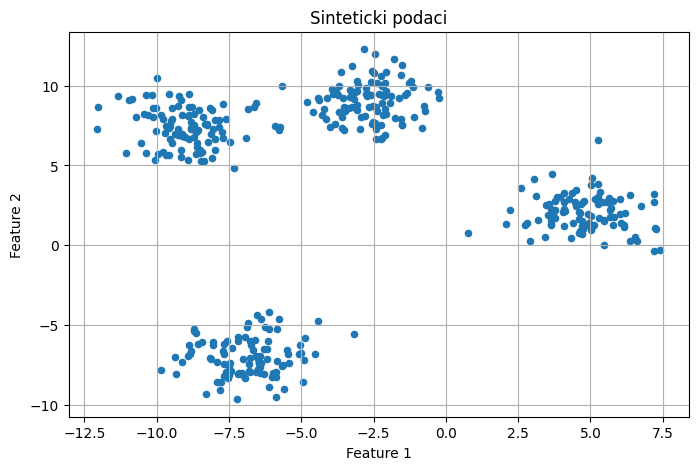

In [6]:
df_blob.plot(
    kind='scatter',
    x='Feature1',
    y='Feature2',
    figsize=(8, 5),
    title='Sinteticki podaci'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

In [9]:
kmeans_blob = KMeans(n_clusters=4, random_state=42, n_init=10)
# Odmah dok treniram model, dobijem vrijednosti za clustere te ih dodam u novi stupac u DataFrameu
df_blob['clusters'] = kmeans_blob.fit_predict(df_blob[['Feature1', 'Feature2']])
df_blob.head(15)

,Feature1,Feature2,clusters
0,-10.375,9.429,3
1,-5.653,10.001,1
2,-9.133,6.996,3
3,5.810,1.797,0
4,5.325,3.336,0
5,-3.449,8.628,1
6,-1.941,8.927,1
7,-8.217,6.453,3
8,-2.405,8.655,1
9,6.381,3.124,0


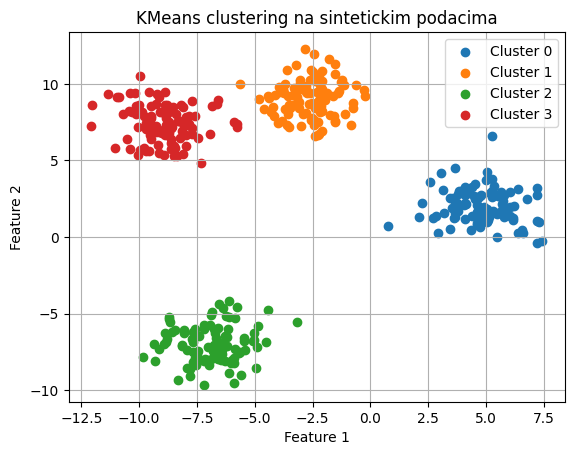

In [11]:
for cluster in sorted(df_blob['clusters'].unique()):
    subset = df_blob[df_blob['clusters'] == cluster]
    plt.scatter(subset['Feature1'], subset['Feature2'], label=f'Cluster {cluster}')

plt.title('KMeans clustering na sintetickim podacima')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

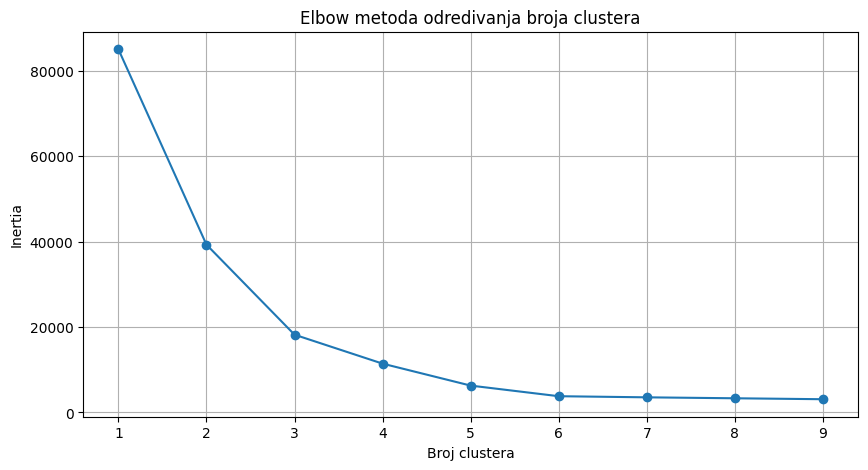

In [19]:
inertias = []
k_values = range(1, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_blob[['Feature1', 'Feature2']])
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow metoda odredivanja broja clustera')
plt.xlabel('Broj clustera')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [12]:
make_blobs?

Signature:
make_blobs(
    n_samples=100,
    n_features=2,
    *,
    centers=None,
    cluster_std=1.0,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=None,
    return_centers=False,
)
Docstring:
Generate isotropic Gaussian blobs for clustering.

Read more in the :ref:`User Guide <sample_generators>`.

Parameters
----------
n_samples : int or array-like, default=100
    If int, it is the total number of points equally divided among
    clusters.
    If array-like, each element of the sequence indicates
    the number of samples per cluster.

    .. versionchanged:: v0.20
        one can now pass an array-like to the ``n_samples`` parameter

n_features : int, default=2
    The number of features for each sample.

centers : int or array-like of shape (n_centers, n_features), default=None
    The number of centers to generate, or the fixed center locations.
    If n_samples is an int and centers is None, 3 centers are generated.
    If n_samples is array-like, centers 

In [14]:
X_blob, y_blob = make_blobs(
    n_samples=1400,
    n_features=4,
    centers=6,
    cluster_std=1.2,
    random_state=42
)

df_blob = pd.DataFrame(X_blob, columns=['Feature1', 'Feature2', 'Feature3', 'Feature4'])
df_blob.head()

,Feature1,Feature2,Feature3,Feature4
0,3.230,-7.021,-5.683,-2.419
1,-5.199,2.558,-2.437,-3.912
2,-2.416,7.981,6.468,2.620
3,-3.570,9.199,4.710,0.602
4,-5.550,-8.128,-8.103,6.059
